# Solución de referencia — ejercicio Beer-Lambert

**Intenta el ejercicio antes de abrir este cuaderno.** La guía está en
[`content/02-ejercicio.md`](../../content/02-ejercicio.md). Si lees la solución
primero, pierdes justo la lección: ver por ti mismo que un ajuste casi perfecto
puede dar una respuesta equivocada.

Este cuaderno es la clave de respuestas del ejercicio. Recorre los milestones
M0 a M6 ya resueltos, con los números exactos que produce el conjunto de datos de
semilla 42.

**Para qué sirve:** comprobar tus propios resultados, y verificar que el ejercicio
sigue funcionando después de cualquier cambio en `generate_data.py`.

**Qué no es:** la forma recomendada de hacer el ejercicio. El ejercicio consiste en
escribir un *skill* (`SKILL.md` + un script corto que el agente ejecuta) — ver
[`SKILL.md.template`](SKILL.md.template). Este cuaderno es lo que ese script
debería calcular.

## Números esperados (semilla 42)

| Pipeline | Predice | Error | R² de calibración |
|---|---|---|---|
| Ingenuo (pico crudo, sin corregir línea base) | 10.78 µM | **+19.8 %** | **0.9998** |
| Con línea base corregida | 9.03 µM | +0.3 % | 0.9998 |
| **Verdad** | **9.00 µM** | — | — |

## Antes de ejecutar

```bash
python generate_data.py     # escribe data/ (ignorado por git)
```

Si `data/` no existe, la primera celda falla. Todo el cuaderno se ejecuta de arriba
a abajo sin intervención.

## Preparación

Nada aquí es específico del taller: cargar CSVs y graficar. Es el mínimo que necesita
cualquier asistente para llegar a M0.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATOS = Path("data")          # generado por: python generate_data.py
LAMBDA_PICO = 664.0           # nm, máximo de absorción del azul de metileno
TOLERANCIA = 0.05             # 5 %, umbral del chequeo de control que se añade en M5


def cargar_espectro(nombre):
    """Devuelve (longitudes de onda, absorbancias) de un CSV del taller."""
    tabla = pd.read_csv(DATOS / nombre)
    return tabla["wavelength_nm"].to_numpy(), tabla["absorbance"].to_numpy()


indice = pd.read_csv(DATOS / "calibration_index.csv")
indice

,filename,concentration_uM
0,calibration_01.csv,2
1,calibration_02.csv,4
2,calibration_03.csv,6
3,calibration_04.csv,8
4,calibration_05.csv,10
5,calibration_06.csv,12


## M0 — Carga y grafica un espectro

*Todo el mundo llega aquí.* Es la prueba de que el entorno funciona y de que los
archivos se leen. Un solo espectro, un solo gráfico, un pico cerca de 664 nm.

> **Nota para el presentador.** Este es el punto de entrada de quien llegue tarde o
> se haya perdido el día 1. No requiere nada de lo anterior. Si alguien no llega a
> M0 en los primeros 10 minutos, el problema es el entorno de Python, no el ejercicio.

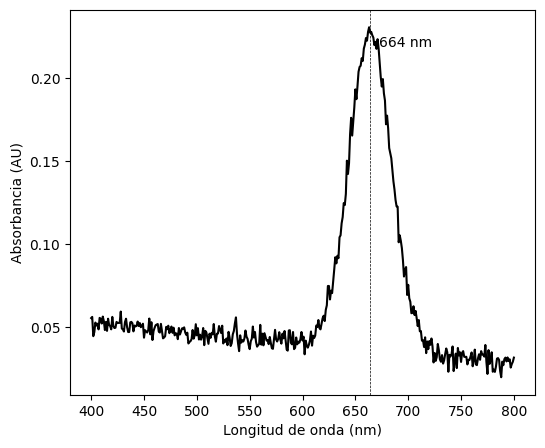

Espectro de 2 µM: 401 puntos, de 400 a 800 nm
Absorbancia máxima: 0.2304 AU


In [2]:
longitudes, absorbancias = cargar_espectro("calibration_01.csv")

plt.figure(figsize=(6, 5))
plt.plot(longitudes, absorbancias, '-k')
plt.axvline(LAMBDA_PICO, color='k', linestyle='--', linewidth=0.5)
plt.text(LAMBDA_PICO + 8, absorbancias.max() * 0.95, '664 nm')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Absorbancia (AU)')
plt.show()

print(f"Espectro de 2 µM: {longitudes.size} puntos, de {longitudes.min():.0f} a {longitudes.max():.0f} nm")
print(f"Absorbancia máxima: {absorbancias.max():.4f} AU")

## M1 — Lee un pico por concentración

Para cada espectro de calibración, una absorbancia de pico emparejada con su
concentración conocida. El primer instinto — y el que casi todos van a escribir —
es tomar el valor más alto de la columna `absorbance`.

> **Nota para el presentador.** Aquí es donde se planta el error. No lo corrijas y
> no lo insinúes: `absorbancias.max()` es la línea que hay que dejar pasar. Si el
> modelo gratuito corrige la línea base por su cuenta, el ejercicio sigue
> funcionando — el punto no es que el modelo se equivoque, sino que sin el
> benchmark no había forma de saber si acertó (plan §7.2).

In [3]:
def leer_pico_crudo(longitudes, absorbancias):
    """Primer instinto: la absorbancia más alta del espectro.

    Ignora las longitudes de onda a propósito — solo busca el valor máximo.
    El argumento está ahí para que este lector y el corregido (M5) se puedan
    intercambiar en la misma función de calibración.
    """
    return absorbancias.max()


filas = []
for nombre, concentracion in zip(indice["filename"], indice["concentration_uM"]):
    longitudes, absorbancias = cargar_espectro(nombre)
    filas.append({
        "archivo": nombre,
        "concentracion_uM": concentracion,
        "pico_crudo_AU": leer_pico_crudo(longitudes, absorbancias),
    })

calibracion = pd.DataFrame(filas)
calibracion

,archivo,concentracion_uM,pico_crudo_AU
0,calibration_01.csv,2,0.2304
1,calibration_02.csv,4,0.4176
2,calibration_03.csv,6,0.6015
3,calibration_04.csv,8,0.8089
4,calibration_05.csv,10,0.9928
5,calibration_06.csv,12,1.1816


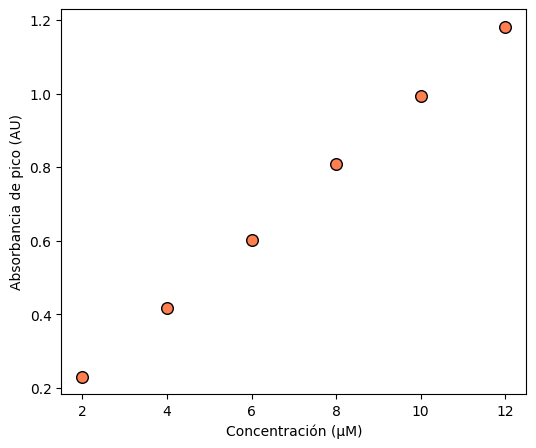

In [4]:
plt.figure(figsize=(6, 5))
plt.scatter(calibracion["concentracion_uM"], calibracion["pico_crudo_AU"],
            s=70, facecolor='coral', edgecolor='black')
plt.xlabel('Concentración (µM)')
plt.ylabel('Absorbancia de pico (AU)')
plt.show()

## M2 — Ajusta la recta de calibración

Beer-Lambert predice $A = \varepsilon\,l\,c$, es decir una recta que pasa por el
origen. Ajustamos pendiente, intersección y R².

In [5]:
def ajustar_recta(x, y):
    """Mínimos cuadrados de primer grado. Devuelve pendiente, intersección y R²."""
    pendiente, interseccion = np.polyfit(x, y, 1)
    predicho = pendiente * x + interseccion
    r2 = 1 - np.sum((y - predicho) ** 2) / np.sum((y - y.mean()) ** 2)
    return pendiente, interseccion, r2


conc = calibracion["concentracion_uM"].to_numpy()
pico = calibracion["pico_crudo_AU"].to_numpy()
pendiente, interseccion, r2 = ajustar_recta(conc, pico)

print(f"pendiente    = {pendiente:.5f} AU/µM")
print(f"intersección = {interseccion:+.5f} AU")
print(f"R²           = {r2:.4f}")

# La pendiente tiene significado físico: ε·l, con ε = 95,000 M⁻¹cm⁻¹ y l = 1 cm.
print(f"\nε·l esperado = {95_000 * 1.0 * 1e-6:.5f} AU/µM  (la pendiente lo reproduce)")

pendiente    = 0.09556 AU/µM
intersección = +0.03657 AU
R²           = 0.9998

ε·l esperado = 0.09500 AU/µM  (la pendiente lo reproduce)


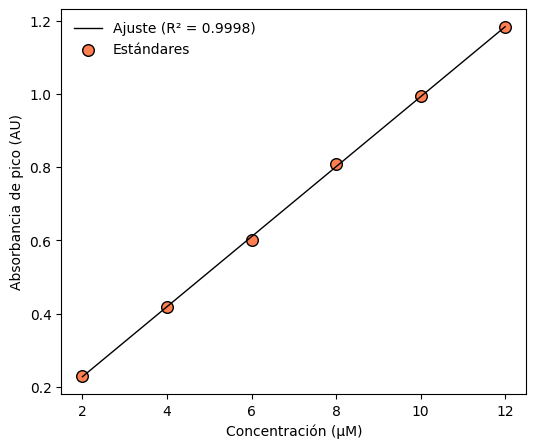

In [6]:
recta = pendiente * conc + interseccion

plt.figure(figsize=(6, 5))
plt.plot(conc, recta, '-k', lw=1, label=f'Ajuste (R² = {r2:.4f})')
plt.scatter(conc, pico, s=70, facecolor='coral', edgecolor='black', label='Estándares')
plt.xlabel('Concentración (µM)')
plt.ylabel('Absorbancia de pico (AU)')
plt.legend(frameon=False)
plt.show()

> **Nota para el presentador — la pista que nadie mira.** La intersección sale en
> **+0.037 AU**, no en cero. Una recta de Beer-Lambert honesta pasa por el origen:
> a concentración cero, absorbancia cero. Esos 0.037 AU son la línea base de los
> espectros de calibración entrando en el ajuste. La evidencia del error ya está
> impresa en pantalla en M2, y aun así nadie la va a señalar, porque el R² de
> 0.9998 domina la atención. Vale la pena volver a esta celda en M5.
>
> Es la versión concreta de la lección: el diagnóstico estaba disponible desde el
> principio; lo que faltaba no era información, sino el hábito de comprobar.

## M3 — Predice la incógnita

Se lee el pico de la incógnita **de la misma forma** que se leyeron los de
calibración, y se invierte la recta.

In [7]:
longitudes_incognita, absorbancias_incognita = cargar_espectro("unknown.csv")
pico_incognita = leer_pico_crudo(longitudes_incognita, absorbancias_incognita)
concentracion_predicha = (pico_incognita - interseccion) / pendiente

print(f"pico de la incógnita     = {pico_incognita:.4f} AU")
print(f"concentración predicha   = {concentracion_predicha:.2f} µM")

pico de la incógnita     = 1.0668 AU
concentración predicha   = 10.78 µM


Este es el falso resumen: los datos cargaron, el ajuste fue casi perfecto y el
pipeline entregó un número concreto con dos decimales. Un asistente que se detenga
aquí reporta **10.78 µM** y se va convencido.

## M4 — Compara contra la verdad

El momento del ejercicio. La concentración verdadera se revela ahora.

> **Nota para el presentador.** El resultado de M4 ya está anunciado en la primera
> sección de `content/02-ejercicio.md` — no se está escondiendo una sorpresa. Lo que
> importa no es el asombro, es que cada quien **calcule su propio número antes de
> ver el verdadero**. Por eso `ground_truth.txt` no se reparte antes de este punto.

In [8]:
print((DATOS / "ground_truth.txt").read_text())

GROUND TRUTH -- do not hand out before milestone M4
Unknown true concentration : 9.000 uM
Molar absorptivity (epsilon): 95,000 M^-1 cm^-1
Path length                : 1 cm
Peak wavelength            : 664 nm
Calibration concentrations : 2, 4, 6, 8, 10, 12 uM
Random seed                : 42

Expected results for this seed (reference pipelines):
  Naive (no baseline correction): predicts 10.78 uM  (error +19.8 %),  calibration R2 = 0.9998
  Baseline-corrected           : predicts 9.03 uM  (error +0.3 %),  calibration R2 = 0.9998

The lesson: the naive calibration looks near-perfect (high R2) yet the
prediction is confidently wrong. Only the benchmark against this true value
exposes it. A good skill bakes that check in and fails loudly.



In [9]:
CONCENTRACION_VERDADERA = 9.00     # µM, de data/ground_truth.txt

error_pct = 100 * (concentracion_predicha - CONCENTRACION_VERDADERA) / CONCENTRACION_VERDADERA

print(f"predicción  : {concentracion_predicha:.2f} µM")
print(f"verdad      : {CONCENTRACION_VERDADERA:.2f} µM")
print(f"error       : {error_pct:+.1f} %")
print(f"R² del ajuste: {r2:.4f}   <-- casi perfecto, y aun así el número está mal")

predicción  : 10.78 µM
verdad      : 9.00 µM
error       : +19.8 %
R² del ajuste: 0.9998   <-- casi perfecto, y aun así el número está mal


**La lección en una línea: un ajuste perfecto no es una respuesta correcta.**

El R² mide qué tan bien la recta describe los seis puntos de calibración. No dice
nada sobre si el método de lectura del pico es correcto, ni sobre si ese método
sigue siendo válido en un espectro medido en otras condiciones. Los seis puntos son
mutuamente consistentes porque comparten la misma línea base; la incógnita no.

## M5 — Diagnostica, corrige y verifica

### El diagnóstico

Graficar la incógnita junto a los espectros de calibración muestra la causa de
inmediato: la incógnita está montada sobre una línea base más alta.

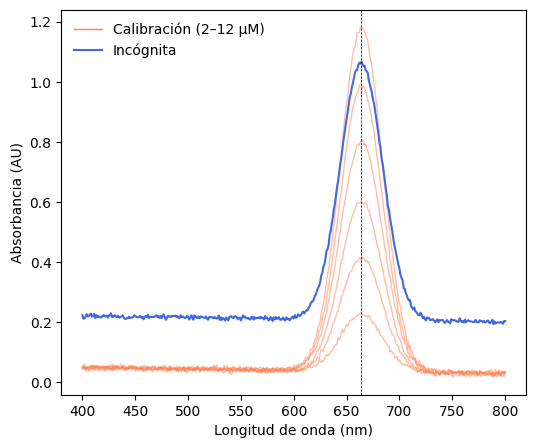

In [10]:
plt.figure(figsize=(6, 5))
for nombre in indice["filename"]:
    lon, abso = cargar_espectro(nombre)
    plt.plot(lon, abso, '-', color='coral', alpha=0.5, lw=1)
plt.plot(longitudes_incognita, absorbancias_incognita, '-', color='royalblue', lw=1.5)
plt.plot([], [], '-', color='coral', lw=1, label='Calibración (2–12 µM)')
plt.plot([], [], '-', color='royalblue', lw=1.5, label='Incógnita')
plt.axvline(LAMBDA_PICO, color='k', linestyle='--', linewidth=0.5)
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Absorbancia (AU)')
plt.legend(frameon=False)
plt.show()

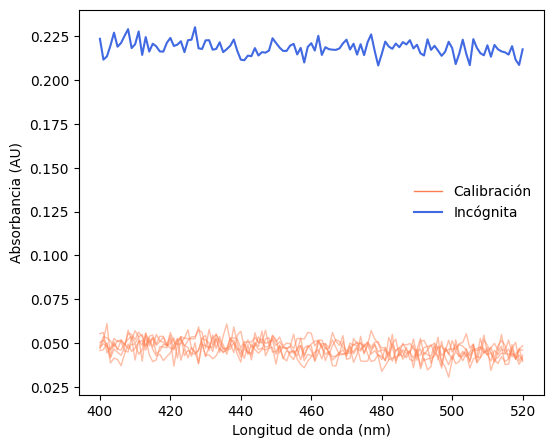

línea base media, calibración : 0.0469 AU
línea base media, incógnita   : 0.2183 AU
diferencia                    : +0.1715 AU

Esa diferencia, dividida por la pendiente (0.09556 AU/µM),
vale 1.79 µM — casi exactamente el error de M4.


In [11]:
# Zoom a la región sin absorción (400–520 nm): ahí solo queda línea base.
region = longitudes_incognita <= 520

plt.figure(figsize=(6, 5))
for nombre in indice["filename"]:
    lon, abso = cargar_espectro(nombre)
    plt.plot(lon[region], abso[region], '-', color='coral', alpha=0.5, lw=1)
plt.plot(longitudes_incognita[region], absorbancias_incognita[region],
         '-', color='royalblue', lw=1.5)
plt.plot([], [], '-', color='coral', lw=1, label='Calibración')
plt.plot([], [], '-', color='royalblue', lw=1.5, label='Incógnita')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Absorbancia (AU)')
plt.legend(frameon=False)
plt.show()

base_calibracion = np.mean([cargar_espectro(n)[1][region].mean() for n in indice["filename"]])
base_incognita = absorbancias_incognita[region].mean()
print(f"línea base media, calibración : {base_calibracion:.4f} AU")
print(f"línea base media, incógnita   : {base_incognita:.4f} AU")
print(f"diferencia                    : {base_incognita - base_calibracion:+.4f} AU")
print(f"\nEsa diferencia, dividida por la pendiente ({pendiente:.5f} AU/µM),")
print(f"vale {(base_incognita - base_calibracion) / pendiente:.2f} µM — casi exactamente el error de M4.")

### La corrección

Se ajusta una recta a las regiones **sin absorción** del colorante (anclas: por
debajo de 520 nm y por encima de 760 nm), se resta, y recién entonces se lee la
altura en 664 nm. Así cada espectro se lee contra su propia línea base.

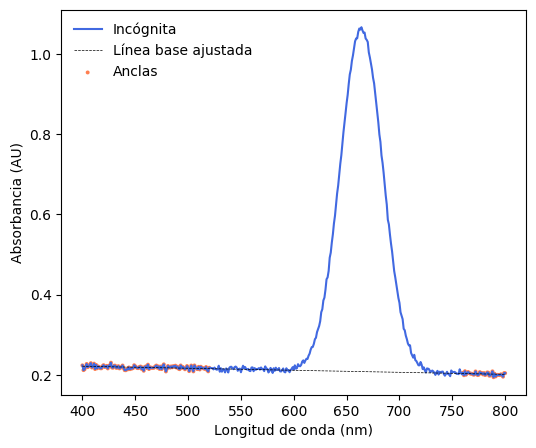

pico crudo     = 1.0668 AU
pico corregido = 0.8588 AU


In [12]:
ANCLA_IZQUIERDA = 520.0    # nm, por debajo el colorante no absorbe
ANCLA_DERECHA = 760.0      # nm, por encima tampoco


def leer_pico_corregido(longitudes, absorbancias):
    """Resta la línea base ajustada en las anclas y lee la altura en 664 nm."""
    anclas = (longitudes <= ANCLA_IZQUIERDA) | (longitudes >= ANCLA_DERECHA)
    coeficientes = np.polyfit(longitudes[anclas], absorbancias[anclas], 1)
    corregido = absorbancias - np.polyval(coeficientes, longitudes)
    return corregido[np.argmin(np.abs(longitudes - LAMBDA_PICO))]


anclas = (longitudes_incognita <= ANCLA_IZQUIERDA) | (longitudes_incognita >= ANCLA_DERECHA)
coef = np.polyfit(longitudes_incognita[anclas], absorbancias_incognita[anclas], 1)

plt.figure(figsize=(6, 5))
plt.plot(longitudes_incognita, absorbancias_incognita, '-', color='royalblue', lw=1.5,
         label='Incógnita')
plt.plot(longitudes_incognita, np.polyval(coef, longitudes_incognita), '--k', lw=0.5,
         label='Línea base ajustada')
plt.scatter(longitudes_incognita[anclas], absorbancias_incognita[anclas],
            s=8, facecolor='coral', edgecolor='none', label='Anclas')
plt.xlabel('Longitud de onda (nm)')
plt.ylabel('Absorbancia (AU)')
plt.legend(frameon=False)
plt.show()

print(f"pico crudo     = {leer_pico_crudo(longitudes_incognita, absorbancias_incognita):.4f} AU")
print(f"pico corregido = {leer_pico_corregido(longitudes_incognita, absorbancias_incognita):.4f} AU")

### El pipeline completo, con un lector intercambiable

Encapsular el pipeline en una función que recibe el *lector de pico* permite correr
el ingenuo y el corregido con el mismo código, y compararlos de forma justa.

In [13]:
def calibrar(lector):
    """Ajusta la recta de calibración usando el lector de pico que se le pase."""
    x = indice["concentration_uM"].to_numpy(dtype=float)
    y = np.array([lector(*cargar_espectro(n)) for n in indice["filename"]])
    pendiente, interseccion, r2 = ajustar_recta(x, y)
    return pendiente, interseccion, r2


def predecir(lector, longitudes, absorbancias, pendiente, interseccion):
    """Invierte la recta de calibración para convertir un espectro en concentración."""
    return (lector(longitudes, absorbancias) - interseccion) / pendiente


for nombre_lector, lector in [("ingenuo", leer_pico_crudo), ("corregido", leer_pico_corregido)]:
    m, b, r = calibrar(lector)
    pred = predecir(lector, longitudes_incognita, absorbancias_incognita, m, b)
    err = 100 * (pred - CONCENTRACION_VERDADERA) / CONCENTRACION_VERDADERA
    print(f"{nombre_lector:>9} : pendiente {m:.5f}  intersección {b:+.5f}  "
          f"R² {r:.4f}  ->  {pred:.2f} µM ({err:+.1f} %)")

  ingenuo : pendiente 0.09556  intersección +0.03657  R² 0.9998  ->  10.78 µM (+19.8 %)
corregido : pendiente 0.09572  intersección -0.00565  R² 0.9998  ->  9.03 µM (+0.3 %)


La intersección es el marcador que faltaba: pasa de **+0.037 AU** (ingenuo) a
**−0.006 AU** (corregido, es decir cero dentro del ruido), como debe ser una recta
de Beer-Lambert. El R² apenas se mueve — sigue en 0.9998 en ambos casos. **El R²
nunca supo nada de este problema.**

### El chequeo que se hornea dentro del skill

Corregir la línea base *esta vez* no es el entregable. El entregable es una
comprobación dentro del skill que falle de forma visible cuando el pipeline se
desvíe — para que la próxima persona (o uno mismo en un mes) no dependa de
acordarse de revisar a mano.

**Aquí hay una trampa de segundo orden, y vale la pena mostrarla en vivo.**

El control obvio es interno: se saca un estándar de calibración del ajuste, se
reajusta con los cinco restantes y se intenta recuperar el que se sacó. Suena
riguroso. Y no sirve.

In [14]:
def control_por_exclusion(lector):
    """Deja fuera un estándar, reajusta con el resto e intenta recuperarlo."""
    x = indice["concentration_uM"].to_numpy(dtype=float)
    espectros = [cargar_espectro(n) for n in indice["filename"]]
    y = np.array([lector(*e) for e in espectros])

    filas = []
    for i, conocido in enumerate(x):
        resto = np.arange(x.size) != i
        m, b = np.polyfit(x[resto], y[resto], 1)
        recuperado = (y[i] - b) / m
        filas.append({
            "conocido_uM": conocido,
            "recuperado_uM": round(recuperado, 3),
            "desviacion_pct": round(100 * (recuperado - conocido) / conocido, 2),
        })
    return pd.DataFrame(filas)


for nombre_lector, lector in [("INGENUO (el que sabemos que está mal)", leer_pico_crudo),
                              ("CORREGIDO (el que sabemos que está bien)", leer_pico_corregido)]:
    tabla = control_por_exclusion(lector)
    peor = tabla["desviacion_pct"].abs().max()
    veredicto = "REPRUEBA" if peor > 100 * TOLERANCIA else "APRUEBA"
    print(f"Control interno por exclusión — pipeline {nombre_lector}:")
    print(tabla.to_string(index=False))
    print(f"  peor desviación: {peor:.2f} %  ->  un umbral del "
          f"{100 * TOLERANCIA:.0f} % lo {veredicto}\n")

Control interno por exclusión — pipeline INGENUO (el que sabemos que está mal):
 conocido_uM  recuperado_uM  desviacion_pct
         2.0          2.060            2.98
         4.0          3.982           -0.44
         6.0          5.892           -1.79
         8.0          8.101            1.26
        10.0         10.010            0.10
        12.0         11.964           -0.30
  peor desviación: 2.98 %  ->  un umbral del 5 % lo APRUEBA

Control interno por exclusión — pipeline CORREGIDO (el que sabemos que está bien):
 conocido_uM  recuperado_uM  desviacion_pct
         2.0          2.106            5.31
         4.0          3.885           -2.87
         6.0          6.010            0.17
         8.0          7.999           -0.02
        10.0         10.063            0.63
        12.0         11.954           -0.39
  peor desviación: 5.31 %  ->  un umbral del 5 % lo REPRUEBA



**El control interno aprueba el pipeline que está 19.8 % equivocado.** La razón es
estructural: los seis estándares comparten la misma línea base, así que la
intersección del ajuste absorbe ese fondo común y cualquier estándar excluido se
recupera bien. El control mide la consistencia del ajuste consigo mismo, no si el
método de lectura sigue siendo válido en un espectro medido en otras condiciones.

Peor aún, en la segunda tabla: bajo el pipeline **corregido** el estándar de 2 µM se
desvía **+5.3 %** y hace fallar el mismo umbral del 5 %. Es decir, el control interno reprueba el pipeline
bueno y aprueba el malo — la señal está invertida.

> **Nota para el presentador — esto es exactamente el fallo que el taller enseña a
> temer.** Una verificación que no puede detectar el error que existe da una falsa
> confianza *peor* que no verificar, porque ahora hay un `assert` verde respaldando
> el número equivocado. Si tienes tiempo en vivo, este es el mejor minuto del día 2.

**El control correcto es un estándar conocido medido en las mismas condiciones que
la incógnita** — en el laboratorio: una muestra de concentración conocida corrida el
mismo día, con la misma cubeta, en la misma sesión que la muestra que se quiere
cuantificar.

In [15]:
# El conjunto de datos que se reparte NO incluye este control todavía (ver la nota
# de acciones pendientes al final). Se construye aquí con la misma física del
# generador, en un flujo de azar aparte para no alterar los datos de semilla 42.
import generate_data as generador

CONTROL_UM = 7.0     # concentración conocida del estándar de control

ruido = np.random.default_rng(43)
absorbancias_control = generador.spectrum(
    CONTROL_UM,
    generador.UNKNOWN_BASELINE_OFFSET,   # misma línea base que la incógnita:
    generador.UNKNOWN_BASELINE_SLOPE,    # "medido en la misma sesión"
    ruido,
)
longitudes_control = generador.WAVELENGTHS

print(f"Estándar de control sintético: {CONTROL_UM:.1f} µM, línea base de la incógnita.")

Estándar de control sintético: 7.0 µM, línea base de la incógnita.


In [16]:
def verificar_control(lector, pendiente, interseccion, tolerancia=TOLERANCIA):
    """Pasa un estándar conocido por el pipeline y falla ruidosamente si se desvía.

    Esta es la comprobación que va DENTRO del skill. Si falla, el skill no reporta
    ninguna concentración: se detiene y dice por qué.
    """
    recuperado = predecir(lector, longitudes_control, absorbancias_control,
                          pendiente, interseccion)
    desviacion = abs(recuperado - CONTROL_UM) / CONTROL_UM
    if desviacion > tolerancia:
        raise ValueError(
            f"CHEQUEO DE CONTROL FALLIDO: el estándar de {CONTROL_UM:.1f} µM se recuperó "
            f"como {recuperado:.2f} µM ({100 * desviacion:.1f} % de desviación, "
            f"tolerancia {100 * tolerancia:.0f} %). No se reporta ninguna concentración."
        )
    return recuperado, desviacion


for nombre_lector, lector in [("ingenuo", leer_pico_crudo), ("corregido", leer_pico_corregido)]:
    m, b, _ = calibrar(lector)
    try:
        recuperado, desviacion = verificar_control(lector, m, b)
        pred = predecir(lector, longitudes_incognita, absorbancias_incognita, m, b)
        print(f"{nombre_lector:>9} : control OK ({recuperado:.2f} µM, "
              f"{100 * desviacion:.1f} %)  ->  se reporta {pred:.2f} µM")
    except ValueError as fallo:
        print(f"{nombre_lector:>9} : {fallo}")

  ingenuo : CHEQUEO DE CONTROL FALLIDO: el estándar de 7.0 µM se recuperó como 8.77 µM (25.3 % de desviación, tolerancia 5 %). No se reporta ninguna concentración.
corregido : control OK (7.00 µM, 0.1 %)  ->  se reporta 9.03 µM


Eso es lo que se busca: **el pipeline ingenuo ya no puede reportar un número.** Se
detiene solo, con un mensaje que dice cuánto se desvió y contra qué. El corregido
pasa el control con −0.1 % y reporta 9.03 µM.

La diferencia con M4 es importante: en M4 el error se detectó porque el instructor
reveló la respuesta. Aquí se detecta **sin conocer la respuesta** — el control es
una muestra conocida, no la incógnita. Eso es lo que hace que el skill sirva mañana,
con datos cuya respuesta nadie sabe.

## M6 — Endurece (vía rápida)

Para quien llegue temprano. Ninguno de los tres pasos es obligatorio.

### Residuales del ajuste

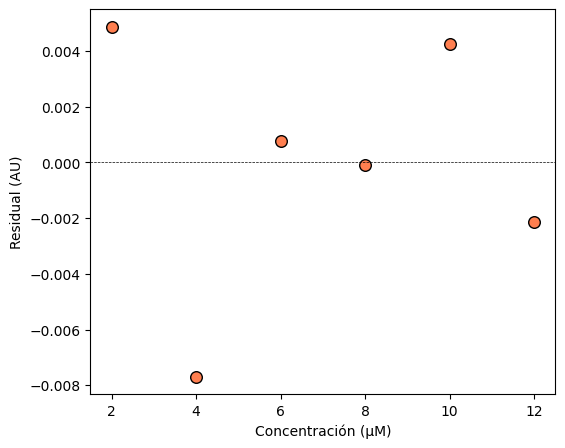

residuales (AU): [ 0.0049 -0.0077  0.0008 -0.0001  0.0043 -0.0021]
desviación estándar del ajuste: 0.00515 AU


In [17]:
m_corr, b_corr, r2_corr = calibrar(leer_pico_corregido)
x_cal = indice["concentration_uM"].to_numpy(dtype=float)
y_cal = np.array([leer_pico_corregido(*cargar_espectro(n)) for n in indice["filename"]])
residuales = y_cal - (m_corr * x_cal + b_corr)

plt.figure(figsize=(6, 5))
plt.axhline(0, color='k', linestyle='--', linewidth=0.5)
plt.scatter(x_cal, residuales, s=70, facecolor='coral', edgecolor='black')
plt.xlabel('Concentración (µM)')
plt.ylabel('Residual (AU)')
plt.show()

print("residuales (AU):", np.round(residuales, 4))
print(f"desviación estándar del ajuste: {np.sqrt(np.sum(residuales**2) / (x_cal.size - 2)):.5f} AU")

Sin patrón visible y del orden del ruido del detector (0.004 AU) — el ajuste lineal
es adecuado. Vale la pena señalar que este mismo gráfico, hecho sobre el pipeline
**ingenuo**, también sale limpio: los residuales tampoco detectan el problema,
porque el problema no está en el ajuste.

### Guarda de extrapolación

In [18]:
def guarda_de_rango(concentracion, concentraciones_calibradas):
    """Avisa si la concentración predicha cae fuera del rango calibrado."""
    minimo, maximo = concentraciones_calibradas.min(), concentraciones_calibradas.max()
    dentro = minimo <= concentracion <= maximo
    return dentro, minimo, maximo


for etiqueta, valor in [("ingenuo (10.78 µM)", 10.78), ("corregido (9.03 µM)", 9.03)]:
    dentro, minimo, maximo = guarda_de_rango(valor, x_cal)
    print(f"{etiqueta:>20} : dentro de [{minimo:.0f}, {maximo:.0f}] µM -> {dentro}")

  ingenuo (10.78 µM) : dentro de [2, 12] µM -> True
 corregido (9.03 µM) : dentro de [2, 12] µM -> True


> **Nota para el presentador.** La guarda de rango **tampoco** habría detectado el
> error de M4: 10.78 µM cae cómodamente dentro del rango calibrado de 2 a 12 µM. Es
> una guarda útil y vale la pena tenerla, pero contra otro modo de falla. Decirlo en
> voz alta refuerza la lección central: cada verificación cubre un error específico,
> y ninguna cubre todos. La única que atrapó *este* error fue el control medido en
> las condiciones de la incógnita.

### Propagación de incertidumbre

In [19]:
def concentracion_con_incertidumbre(absorbancia, x_cal, y_cal, pendiente, interseccion):
    """Devuelve (concentración, incertidumbre 1σ) para una absorbancia leída.

    Fórmula estándar de la incertidumbre de una predicción inversa en una
    calibración lineal (una sola medición de la incógnita).
    """
    n = x_cal.size
    residuales = y_cal - (pendiente * x_cal + interseccion)
    s_yx = np.sqrt(np.sum(residuales ** 2) / (n - 2))          # error estándar del ajuste
    c = (absorbancia - interseccion) / pendiente
    s_c = (s_yx / pendiente) * np.sqrt(1 + 1 / n + (c - x_cal.mean()) ** 2
                                       / np.sum((x_cal - x_cal.mean()) ** 2))
    return c, s_c


absorbancia_incognita = leer_pico_corregido(longitudes_incognita, absorbancias_incognita)
c, s_c = concentracion_con_incertidumbre(absorbancia_incognita, x_cal, y_cal, m_corr, b_corr)

print(f"concentración reportada : {c:.2f} ± {s_c:.2f} µM (1σ)")
print(f"verdad                  : {CONCENTRACION_VERDADERA:.2f} µM")
print(f"¿la verdad cae dentro de ±1σ? {abs(c - CONCENTRACION_VERDADERA) <= s_c}")

concentración reportada : 9.03 ± 0.06 µM (1σ)
verdad                  : 9.00 µM
¿la verdad cae dentro de ±1σ? True


## Resumen — los números que debes tener a mano

| Milestone | Resultado | Comentario |
|---|---|---|
| M1 | 6 picos crudos, 0.23–1.20 AU | el error ya está dentro |
| M2 | pendiente 0.09556 AU/µM, intersección **+0.0366 AU**, R² **0.9998** | la intersección era la pista |
| M3 | **10.78 µM** | número seguro de sí mismo |
| M4 | verdad **9.00 µM**, error **+19.8 %** | con R² = 0.9998 intacto |
| M5 corrección | **9.03 µM**, error **+0.3 %**, intersección −0.0057 AU | R² sigue en 0.9998 |
| M5 control interno | ingenuo pasa (peor 3.0 %) | **falso positivo** |
| M5 control de sesión | ingenuo falla (+25.3 %), corregido pasa (−0.1 %) | el chequeo que sirve |
| M6 incertidumbre | 9.03 ± 0.06 µM (1σ) | la verdad cae dentro |

## La lección, y qué debe contener el skill del asistente

**Un skill de investigación en el que puedes confiar es uno que se comprueba a sí mismo
— contra algo cuya respuesta ya conoces, medido como se midió tu muestra.**

Lista de comprobación para revisar el `SKILL.md` de un asistente:

- [ ] Corrige la línea base antes de leer cualquier pico.
- [ ] Ejecuta un control conocido por el pipeline **antes** de reportar.
- [ ] Falla de forma visible (se detiene, no reporta) si el control se desvía más de la tolerancia.
- [ ] Muestra el gráfico de calibración, el R² y el resultado del control — no solo el número final.
- [ ] Se niega a reportar si la incógnita cae fuera del rango calibrado.
- [ ] El control se mide en las condiciones de la incógnita, no se toma de la propia calibración.

Ese último punto es el que ningún asistente va a poner por su cuenta, y es el que
convierte el chequeo en algo real. Vale la pena dedicarle los últimos cinco minutos
del bloque.

---

## Acciones pendientes para el presentador

Dos cosas que este cuaderno destapó y que hay que decidir **antes** del día 2. Son
decisiones tuyas, no cambios que se hayan hecho:

1. **El conjunto de datos no incluye un estándar de control.** `generate_data.py`
   emite seis espectros de calibración y una incógnita, nada más. El chequeo de M5
   tal como está descrito en `content/02-ejercicio.md` y en `SKILL.md.template`
   ("corre un control conocido por el pipeline") solo se puede satisfacer con un
   control interno de calibración — que, como muestra este cuaderno, **aprueba el
   pipeline equivocado**. Para que M5 funcione como se diseñó, `generate_data.py`
   tiene que emitir también un `control.csv`: concentración conocida (7 µM sirve),
   con la línea base de la incógnita, declarado a los asistentes como "un estándar
   conocido medido en la misma sesión que la incógnita". Este cuaderno lo construye
   en memoria para poder demostrar el punto; los asistentes no lo tendrían.

2. **Si se añade el control, el texto de M5 necesita una línea más.** Tanto
   `content/02-ejercicio.md` (M5) como `SKILL.md.template` (M5) piden "un control
   conocido" sin especificar en qué condiciones fue medido. Esa omisión es
   justamente lo que lleva al control interno y al falso positivo. Basta con
   explicitar: *el control debe haberse medido en las mismas condiciones que la
   incógnita*.

Ninguna de las dos cosas invalida el ejercicio tal como está: M0–M4 funcionan sin
tocar nada, y M5 se puede narrar en vivo con este cuaderno. Pero si los asistentes
tienen que **escribir** el chequeo ellos mismos, necesitan el archivo de control.

Sigue abierto el riesgo del plan §10 que este cuaderno **no** cubre: correr el
ejercicio completo en opencode con el modelo gratuito, a ritmo de asistente lento,
para confirmar que M0–M4 caben en 40 minutos y saber si el modelo comete o evita el
error de línea base por su cuenta.